# MATH 232 - Math Models w/ Tech
## Multiple Linear Regression, Testing & Training Error
### Instructor: Prof. Mario Bañuelos 

In [2]:
# Import necessary packages
from IPython.display import HTML, Image
import numpy as np
from scipy import linalg as la
from scipy import sparse
import pandas as pd
# import plotting packages
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

## Outline

* [Multiple Linear Regression](#mlr)
  * [Simulated Data](#sim)
  * [Advertising Data](#advert)
  * [Model Accuracy](#model-acc)
* [Testing and Training ](#test-train) 
  * [Choosing Test/Train Split](#split)
* [Further Reading](#reading)

# Multiple Linear Regression <a id='mlr'></a>


We 

$$
Y \approx \beta_0 + \beta_1 X,
$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope. 

Let's simulate some of this data where $X$ is only one-dimensional and we want to predict the quantitative response $Y$.


### Warm-Up 1 (5 min).

Modify the `simulate_linear` code so that you code above to have 
* $x$ is drawn from a $N(\mu = 10, \sigma^2 = 1)$ distribution
* add some noise (or error) to the simulated data, so that all points do not lie on the line

In [17]:
def simulate_mlr(num, b0, b1, b2, random_seed):
    # set random seed
    np.random.seed(random_seed)
    # set mean and sd
    sigma_1 = 1
    mu_1 = 10
    sigma_2 = 2
    mu_2 = 5
    # draw samples from a standard normal distribution
    x1 = sigma_1 * np.random.randn(num) + mu_1
    x2 = sigma_2 * np.random.randn(num) + mu_2
    noise = 1.5 * np.random.randn(num)
    y = b0 + b1*x1 + b2*x2 + noise
    
    return [x1,x2],y

In [ ]:
# simulate and plot data
X,Y = simulate_mlr(800,3,2,5,random_seed=2)

# 3d figure
fig = go.Figure(data=[go.Scatter3d(
    x=X[0],
    y=X[1],
    z=Y,
    mode='markers'
)])

In [19]:
fig.show()

Download the <a href="https://www.dropbox.com/s/xk8n5b4f43n355n/Advertising.csv?dl=1"> Advertising data </a>

Typically, we do not know the values of $\beta$s, so we need to estimate them and our estimates can be written as 

$$
\hat{f} = \hat{y} =\hat{\beta}_0 + \hat{\beta}_1 X,
$$

where $\hat{\beta}_0$ is the *estimated intercept* and $\hat{\beta}_1$ is the *estimated slope*. 

How do we estimate these parameters?


## Assessing Model Accuracy <a id='model-acc'></a>

In regression settings, we can use the *residual sum of squares (RSS)* (generally known as the loss function $\mathcal{L}$), which is defined as

$$
\mathcal{L} = RSS = \sum^{n}_{i=1} \left( y_i - \hat{y_i}\right)^2 = \sum^{n}_{i=1} \left( y_i - \hat{f}(x_i)\right)^2 =  \sum^{n}_{i=1} \left( y_i - [\hat{\beta}_0 + \hat{\beta}_1 x_i]\right)^2
$$

where $\hat{f}(x_i)$ is the prediction that $\hat{f}$ gives for the $i$th observation. 

**Goal:** Minimize the *RSS*! 

How do we minimize quadratic functions?

### Breakout Question.

Calculate $\frac{\partial RSS}{\partial \hat{\beta}_0}$ and $\frac{\partial RSS}{\partial \hat{\beta}_1}$, set them equal to zero and solve for $\hat{\beta}$s.

# Gradient Descent <a id='grad'></a>

A question that arises is how do we estimate the $\hat{\beta}$ values if we cannot set the derivative to zero?

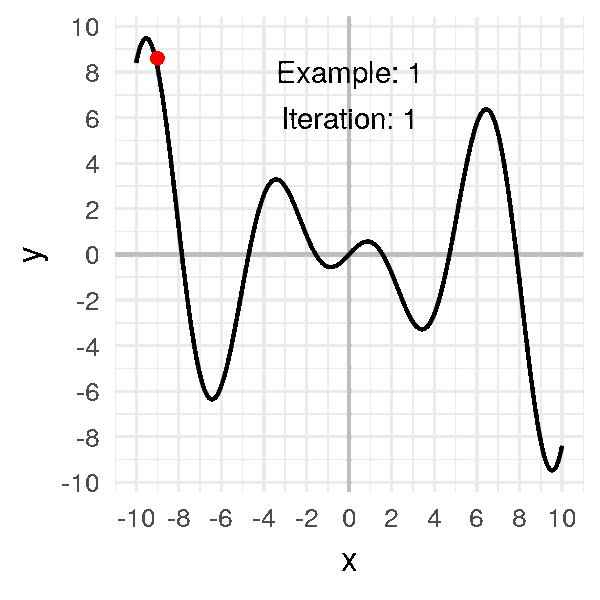

In [22]:
Image('https://www.charlesbordet.com/assets/images/gradient-descent/gradientdescent-f3.gif')

## Gradient Descent Algorithm

0. 
 * Set $\eta$ (the learning rate, also known as step-size)
 * Set number of iterations


 1. Initialize $\hat{\beta}_0$ and $\hat{\beta}_1$
 2. Calculate the partial derivatives of the loss function with respect to the $\hat{\beta}$s
 3. Update $\hat{\beta}_0$ and $\hat{\beta}_1$ by the following rule:
     $$
     \hat{\beta}_0 = \hat{\beta}_{0 (old)} - \eta \times \frac{\mathcal{\partial L}}{\partial \hat{\beta}_0}\\
     \hat{\beta}_1 = \hat{\beta}_{1 (old)} - \eta \times \frac{\mathcal{\partial L}}{\partial \hat{\beta}_1}
     $$
 4. Repeat 1-3 until the number of iterations is reached.


### Breakout Session.

In your breakout rooms, write a function that takes in a *loss function gradient, $\eta$,* and the number of iterations $n$, and implements gradient descent. Divide and conquer this problem as follows:

 * one writes the function for the loss function 
 * one (or two) write the function for the gradient of the loss function
 * one person writes the gradient descent function which incorporates the above and plots
 
**Instead of copying and pasting into the chat**, I encourage you to try <a href="https://codeshare.io/"> codeshare.io </a> so you can all collaborate on the code (... and then all copy it to your notebook). *Note: you do not need to make an account but your code disappears after 24 hours*

# Team Contract Time <a id='team-contract'></a>

* For the remaining time, begin discussing your team contract and potential project topic.

## Further Reading <a id="reading"></a>


* <a href="http://faculty.marshall.usc.edu/gareth-james/ISL/ISLR%20Seventh%20Printing.pdf"> Introduction to Statistical Learning
</a>